In [1]:
import pandas as pd
df=pd.read_csv("marketing_campaign_cleaned.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Total_Spending
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,69,1617
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,72,27
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,3,11,0,61,776
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,3,11,0,42,53
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,3,11,0,45,422


In [2]:
# Customer Overview
print("Total Customers:",df.shape[0])
print("Average Age:",df['Age'].mean())
print("Average Income:",df['Income'].mean())

Total Customers: 2240
Average Age: 57.19419642857143
Average Income: 52237.97544642857


In [3]:
# Customer Segmentation by AGE
bins=[0,35,50,65,100]
labels=['Young','Middle Age','Senior','Old']

df['Age_Group']=pd.cut(df['Age'], bins=bins, labels=labels)
df['Age_Group'].value_counts()

Age_Group
Senior        926
Middle Age    652
Old           616
Young          43
Name: count, dtype: int64

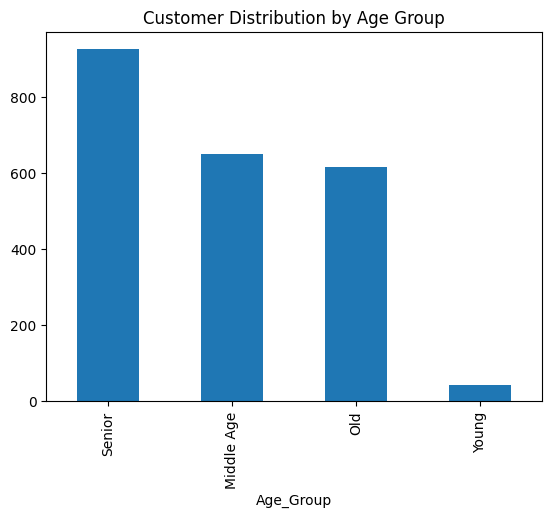

In [4]:
import matplotlib.pyplot as plt
df['Age_Group'].value_counts().plot(kind='bar')
plt.title("Customer Distribution by Age Group")
plt.show()

Insight
-Identify which age group has the highest number of customers.

In [5]:
# Customer Segmentation by INCOME
df['Income_Group']=pd.qcut(df['Income'], q=3, labels=['Low Income','Medium Income','High Income'])

df['Income_Group'].value_counts()

Income_Group
Low Income       747
High Income      747
Medium Income    746
Name: count, dtype: int64

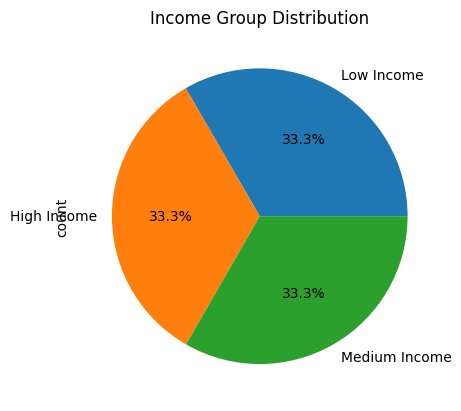

In [6]:
df['Income_Group'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Income Group Distribution")
plt.show()

In [7]:
# Valuable Customers
df.groupby('Income_Group')['Total_Spending'].mean()

C:\Users\vijay\AppData\Local\Temp\ipykernel_28632\4221698910.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_Group')['Total_Spending'].mean()


Income_Group
Low Income         95.635877
Medium Income     457.345845
High Income      1264.214190
Name: Total_Spending, dtype: float64

C:\Users\vijay\AppData\Local\Temp\ipykernel_28632\773386992.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Income_Group')['Total_Spending'].mean().plot(kind='bar')


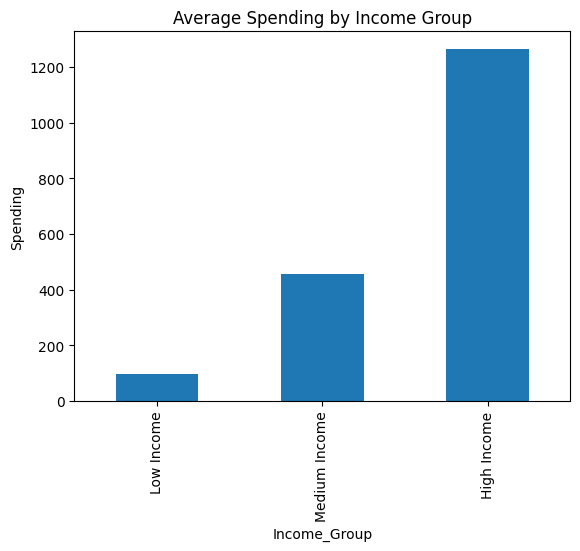

In [8]:
df.groupby('Income_Group')['Total_Spending'].mean().plot(kind='bar')
plt.title("Average Spending by Income Group")
plt.ylabel("Spending")
plt.show()

Insight
-High-income customers generally spend more and are the most valuable group.

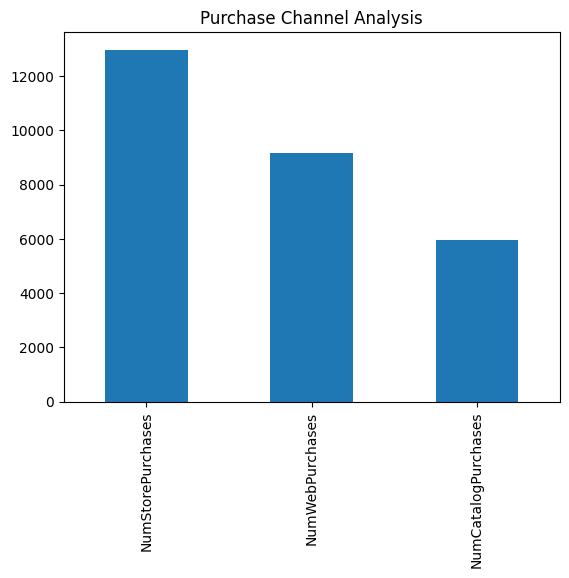

In [9]:
# Purchasing behavior
channels = ['NumStorePurchases',
            'NumWebPurchases',
            'NumCatalogPurchases']

df[channels].sum().plot(kind='bar')
plt.title("Purchase Channel Analysis")
plt.show()

Insight
-Determine whether Store, Web, or Catalog purchases dominate.

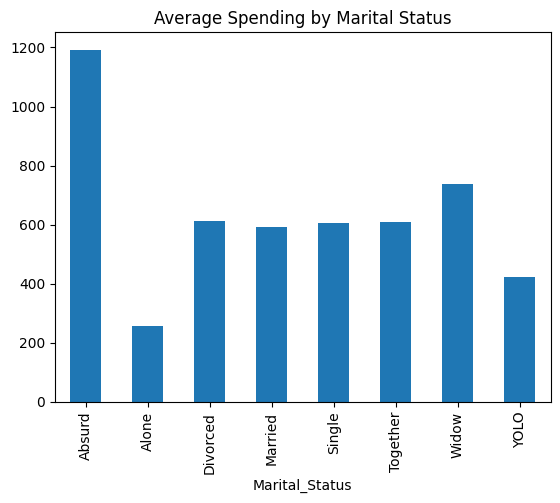

In [10]:
# Marital Status Analysis
df.groupby('Marital_Status')['Total_Spending'].mean().plot(kind='bar')
plt.title("Average Spending by Marital Status")
plt.show()

Insight
-Identify which marital-status group spends the most.

Recommendations
-Target high-income customers with premium offers.
-Focus marketing on the age group with the highest spending.
-Increase online promotions if web purchases are strong.
-Run personalized campaigns for high-value customers.
-Promote wine and meat products since they contribute the most revenue.